# Diffraction gratings

Light with wavelength $\lambda$ is incident on a diffraction grating of total width $w$, gets diffracted, is focused with a lens of focal length $f$, and falls on a screen.

Theory tells us that the intensity of the diffraction pattern on the screen, at a distance $x$ from the central axis of the system, is given by

$$I(x)=\left\lvert \int_{-w/2}^{w/2}\sqrt{q(u)}e^{i2\pi xu/\lambda f}du \right\rvert^{2}$$

where $q(u)$ is the intensity transmission function of the diffraction grating at a distance $u$ from the central axis, or put more simply, the fraction of the incident light that the grating lets through.

We now consider a grating with a transmission function $q(u)=sin^2(\alpha u)$ and a distance $\frac{\pi}{\alpha}$ between each "slits". We also choose the slits to be separated of $20\mu m$.

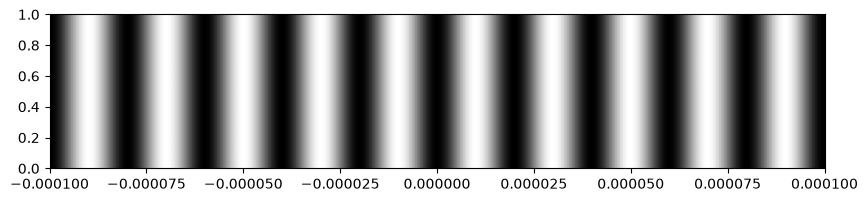

In [121]:
import matplotlib.pyplot as plt
import numpy as np

WAVELENGTH = 20e-6
FOCAL_LENGTH = 1
SEPARATION = 20e-6
SCREEN_SIZE = 0.1
NUMBER_OF_SLITS = 10
GRATING_WIDTH = NUMBER_OF_SLITS * SEPARATION

def transmission(u):
    return np.sin(np.pi / SEPARATION * u)**2

x = np.linspace(-NUMBER_OF_SLITS / 2 * SEPARATION, NUMBER_OF_SLITS / 2 * SEPARATION, 500)
y = transmission(x)

fig, ax = plt.subplots(figsize=(10, 2))
heatmap = np.tile(y, (20, 1))
plt.imshow(heatmap, aspect='auto', cmap='grey', extent=[x.min(), x.max(), 0, 1])
plt.show()

In [122]:
import cmath
import scipy as sc

def integrand(u, x):
    return np.sqrt(transmission(u)) * cmath.exp(1j * 2 * np.pi * x * u / (WAVELENGTH * FOCAL_LENGTH))

def intensity(x):
    return abs((sc.integrate.quad(lambda u: integrand(u, x), 
                                  -GRATING_WIDTH/2, 
                                  GRATING_WIDTH/2, 
                                  limit=100)[0]
              ))**2

/home/guillaume/Documents/python computational physics/integrals and derivatives/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:626: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)
/tmp/ipykernel_27694/574757876.py:8: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return abs((sc.integrate.quad(lambda u: integrand(u, x),


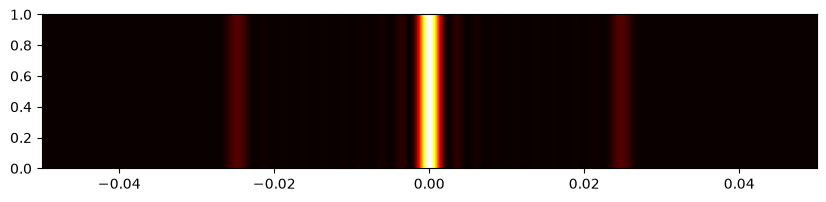

In [123]:
WAVELENGTH = 500e-9
FOCAL_LENGTH = 1

x = np.linspace(-SCREEN_SIZE / 2, SCREEN_SIZE / 2, 500)
i = list(map(lambda z: intensity(z), x))

fig, ax = plt.subplots(figsize=(10, 2))
heatmap = np.tile(i, (20, 1))
plt.imshow(heatmap, aspect='auto', cmap='hot', extent=[x.min(), x.max(), 0, 1])
plt.show()

## Trying out other diffraction patterns

Now we are going to do the same exercise but with two others diffraction patterns. 

The first one will have a transmission profile that obeys $q(u)=sin^2(\alpha u)sin^2(\beta u)$ with the value of $\alpha$ than before and the same total grating width $w$. We'll also use $\beta = \frac{\alpha}{2}$.

The second one will have two "square" slits, meaning slits with 100% transmission through the slit and 0% transmission everywhere else. We'll try non-identical slits, one $10\mu m$ wide and the other $20 \mu m$ wide, with a $60 \mu m$ gap between the two.

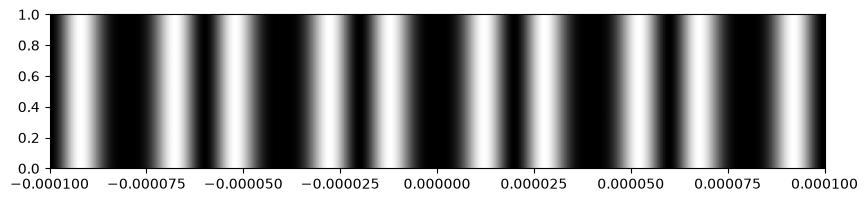

In [ ]:
def transmission(u):
    return np.sin(np.pi / SEPARATION * u)**2 * np.sin(np.pi / (2 * SEPARATION) * u)**2

x = np.linspace(-NUMBER_OF_SLITS / 2 * SEPARATION, NUMBER_OF_SLITS / 2 * SEPARATION, 500)
y = transmission(x)

fig, ax = plt.subplots(figsize=(10, 2))
heatmap = np.tile(y, (20, 1))
plt.imshow(heatmap, aspect='auto', cmap='grey', extent=[x.min(), x.max(), 0, 1])
plt.show()

/home/guillaume/Documents/python computational physics/integrals and derivatives/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:626: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


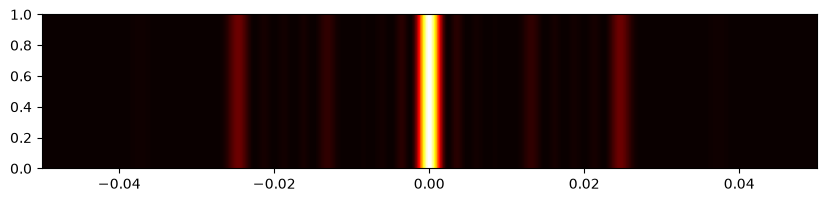

In [129]:
x = np.linspace(-SCREEN_SIZE / 2, SCREEN_SIZE / 2, 500)
i = list(map(lambda z: intensity(z), x))

fig, ax = plt.subplots(figsize=(10, 2))
heatmap = np.tile(i, (20, 1))
plt.imshow(heatmap, aspect='auto', cmap='hot', extent=[x.min(), x.max(), 0, 1])
plt.show()

In [ ]:
def transmission(u):
    if u >= -40e-6 and u <= -30e-6:
        return 1.0
    elif u >= 30e-6 and u <= 50e-6:
        return 1.0
    else:
        return 0.0

x = np.linspace(-NUMBER_OF_SLITS / 2 * SEPARATION, NUMBER_OF_SLITS / 2 * SEPARATION, 500)
y = transmission(x)

fig, ax = plt.subplots(figsize=(10, 2))
heatmap = np.tile(y, (20, 1))
plt.imshow(heatmap, aspect='auto', cmap='grey', extent=[x.min(), x.max(), 0, 1])
plt.show()